<a href="https://colab.research.google.com/github/Adeela-saleem/MachineLearning_Algorithms/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression

**Algorithm:** Linear Regression

**Type:** Supervised Learning

**Problem:** Regression

**Dataset:** Salary_Data.csv

**Language:** Python

**Libraries:** Pandas, NumPy, Matplotlib, Scikit-learn

**Author:** Adeela Saleem

Libraries

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [49]:
from google.colab import files
uploaded=files.upload()

Saving laptopPrice.csv to laptopPrice (2).csv


In [50]:
df=pd.read_csv('laptopPrice.csv')

Basic Info

In [51]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [52]:
df.columns

Index(['brand', 'processor_brand', 'processor_name', 'processor_gnrtn',
       'ram_gb', 'ram_type', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb',
       'weight', 'warranty', 'Touchscreen', 'msoffice', 'Price', 'rating',
       'Number of Ratings', 'Number of Reviews'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    object
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    object
 7   hdd                823 non-null    object
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    object
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  rating             823 non-null    object
 1

In [54]:
df.describe()

,Price,Number of Ratings,Number of Reviews
count,823.000000,823.000000,823.000000
mean,76745.177400,315.301337,37.609964
std,45101.790525,1047.382654,121.728017
min,16990.000000,0.000000,0.000000
25%,46095.000000,0.000000,0.000000
50%,64990.000000,17.000000,2.000000
75%,89636.000000,139.500000,18.000000
max,441990.000000,15279.000000,1947.000000


In [55]:
df.isnull().sum()

,0
brand,0
processor_brand,0
processor_name,0
processor_gnrtn,0
ram_gb,0
ram_type,0
ssd,0
hdd,0
os,0
os_bit,0


In [56]:
df.duplicated().sum()

np.int64(21)

In [57]:
#remove dupliactes
df.drop_duplicates(inplace=True)

In [58]:
df.duplicated().sum()

np.int64(0)

Convert fake-objecct

In [59]:
df.head(2)

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5


In [60]:
df['processor_gnrtn'] = df['processor_gnrtn'].str.replace('th', '', regex=False)
df['processor_gnrtn'] = pd.to_numeric(df['processor_gnrtn'], errors='coerce')

In [61]:
# ram_gb - "4 GB" -> 4
df['ram_gb'] = df['ram_gb'].str.replace('GB', '', regex=False).astype('int32')

In [62]:
# hdd - "1024 GB" -> 1024
df['hdd'] = df['hdd'].str.replace('GB', '', regex=False).astype('int32')


In [63]:
# os_bit - "64-bit" -> 64
df['os_bit'] = df['os_bit'].str.replace('-bit', '', regex=False).astype('int32')


In [92]:
# ssd - "512 GB" -> 512
df['ssd'] = df['ssd'].astype(str).str.replace('GB', '', regex=False)
df['ssd'] = pd.to_numeric(df['ssd'], errors='coerce').astype('int32')

In [64]:
# graphic_card_gb - "0 GB" -> 0
df['graphic_card_gb'] = df['graphic_card_gb'].str.replace('GB', '', regex=False).astype('int32')


In [66]:
# rating - "3 stars" -> 3
df['rating'] = df['rating'].str.replace(' stars', '', regex=False).str.replace(' star', '', regex=False)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [67]:
numerical_cols = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['processor_gnrtn', 'ram_gb', 'hdd', 'os_bit', 'graphic_card_gb', 'Price', 'rating', 'Number of Ratings', 'Number of Reviews']
Categorical: ['brand', 'processor_brand', 'processor_name', 'ram_type', 'ssd', 'os', 'weight', 'warranty', 'Touchscreen', 'msoffice']


In [69]:
df.isnull().sum()

,0
brand,0
processor_brand,0
processor_name,0
processor_gnrtn,224
ram_gb,0
ram_type,0
ssd,0
hdd,0
os,0
os_bit,0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 802 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              802 non-null    object 
 1   processor_brand    802 non-null    object 
 2   processor_name     802 non-null    object 
 3   processor_gnrtn    802 non-null    float64
 4   ram_gb             802 non-null    int32  
 5   ram_type           802 non-null    object 
 6   ssd                802 non-null    object 
 7   hdd                802 non-null    int32  
 8   os                 802 non-null    object 
 9   os_bit             802 non-null    int32  
 10  graphic_card_gb    802 non-null    int32  
 11  weight             802 non-null    object 
 12  warranty           802 non-null    object 
 13  Touchscreen        802 non-null    object 
 14  msoffice           802 non-null    object 
 15  Price              802 non-null    int64  
 16  rating             802 non-null

In [93]:
df['ssd'].unique()

array([   0,  512,  256,  128, 1024, 2048, 3072], dtype=int32)

Univariant

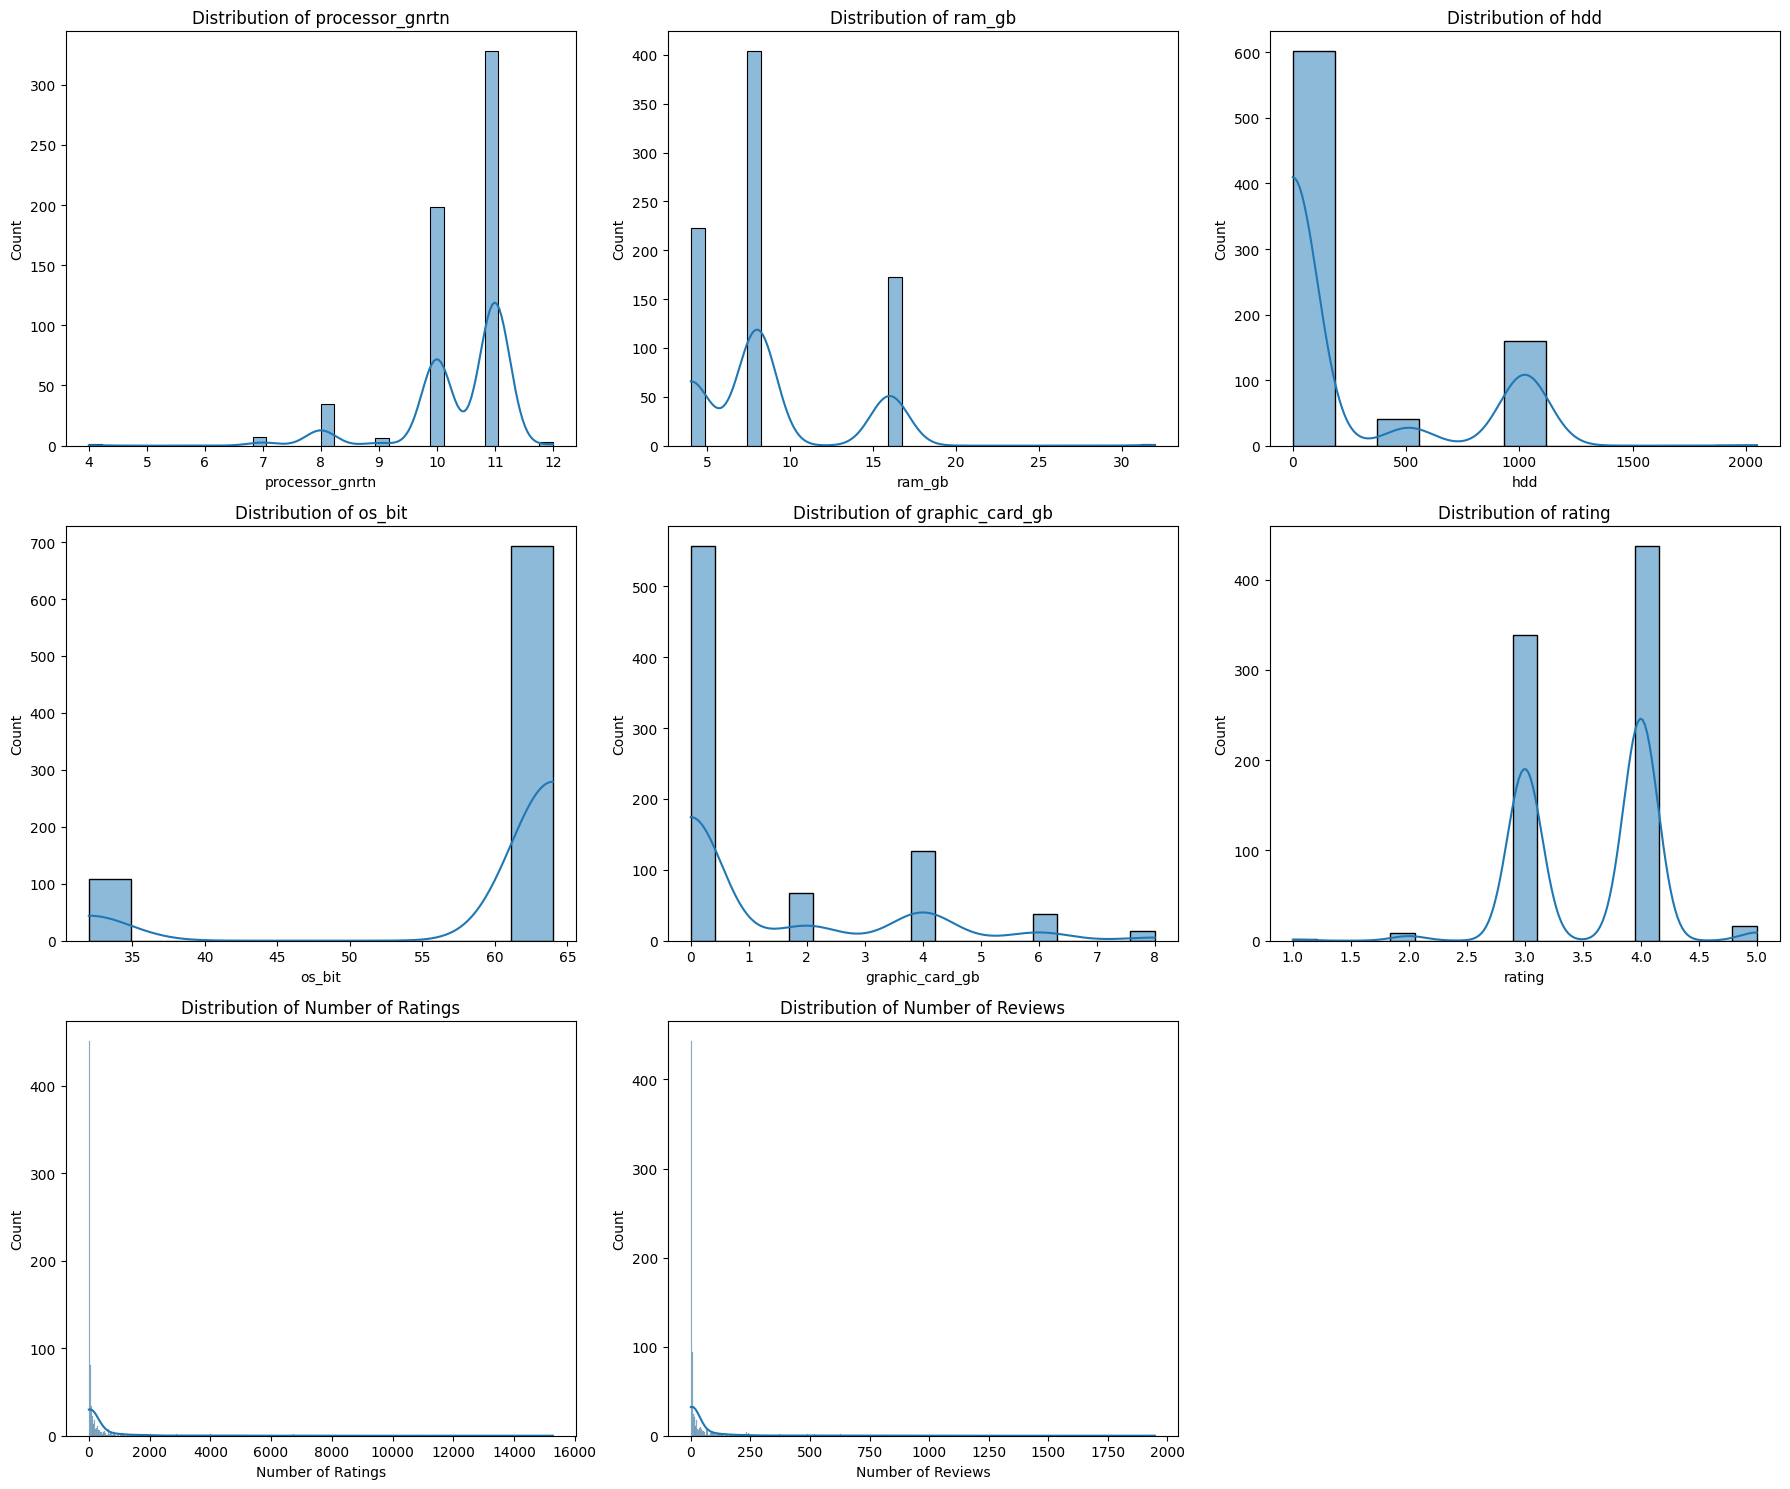

In [80]:
num_cols = df.select_dtypes(include=['int64','float64','int32','float32']).columns.tolist()

# Exclude 'Price' from numerical columns if it's there, as it's often the target variable.
if 'Price' in num_cols:
    num_cols.remove('Price')

num_features = len(num_cols)
num_rows = (num_features + 2) // 3  # Roughly 3 columns per row for better layout

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove any unused subplots if the number of features is not a perfect multiple of 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

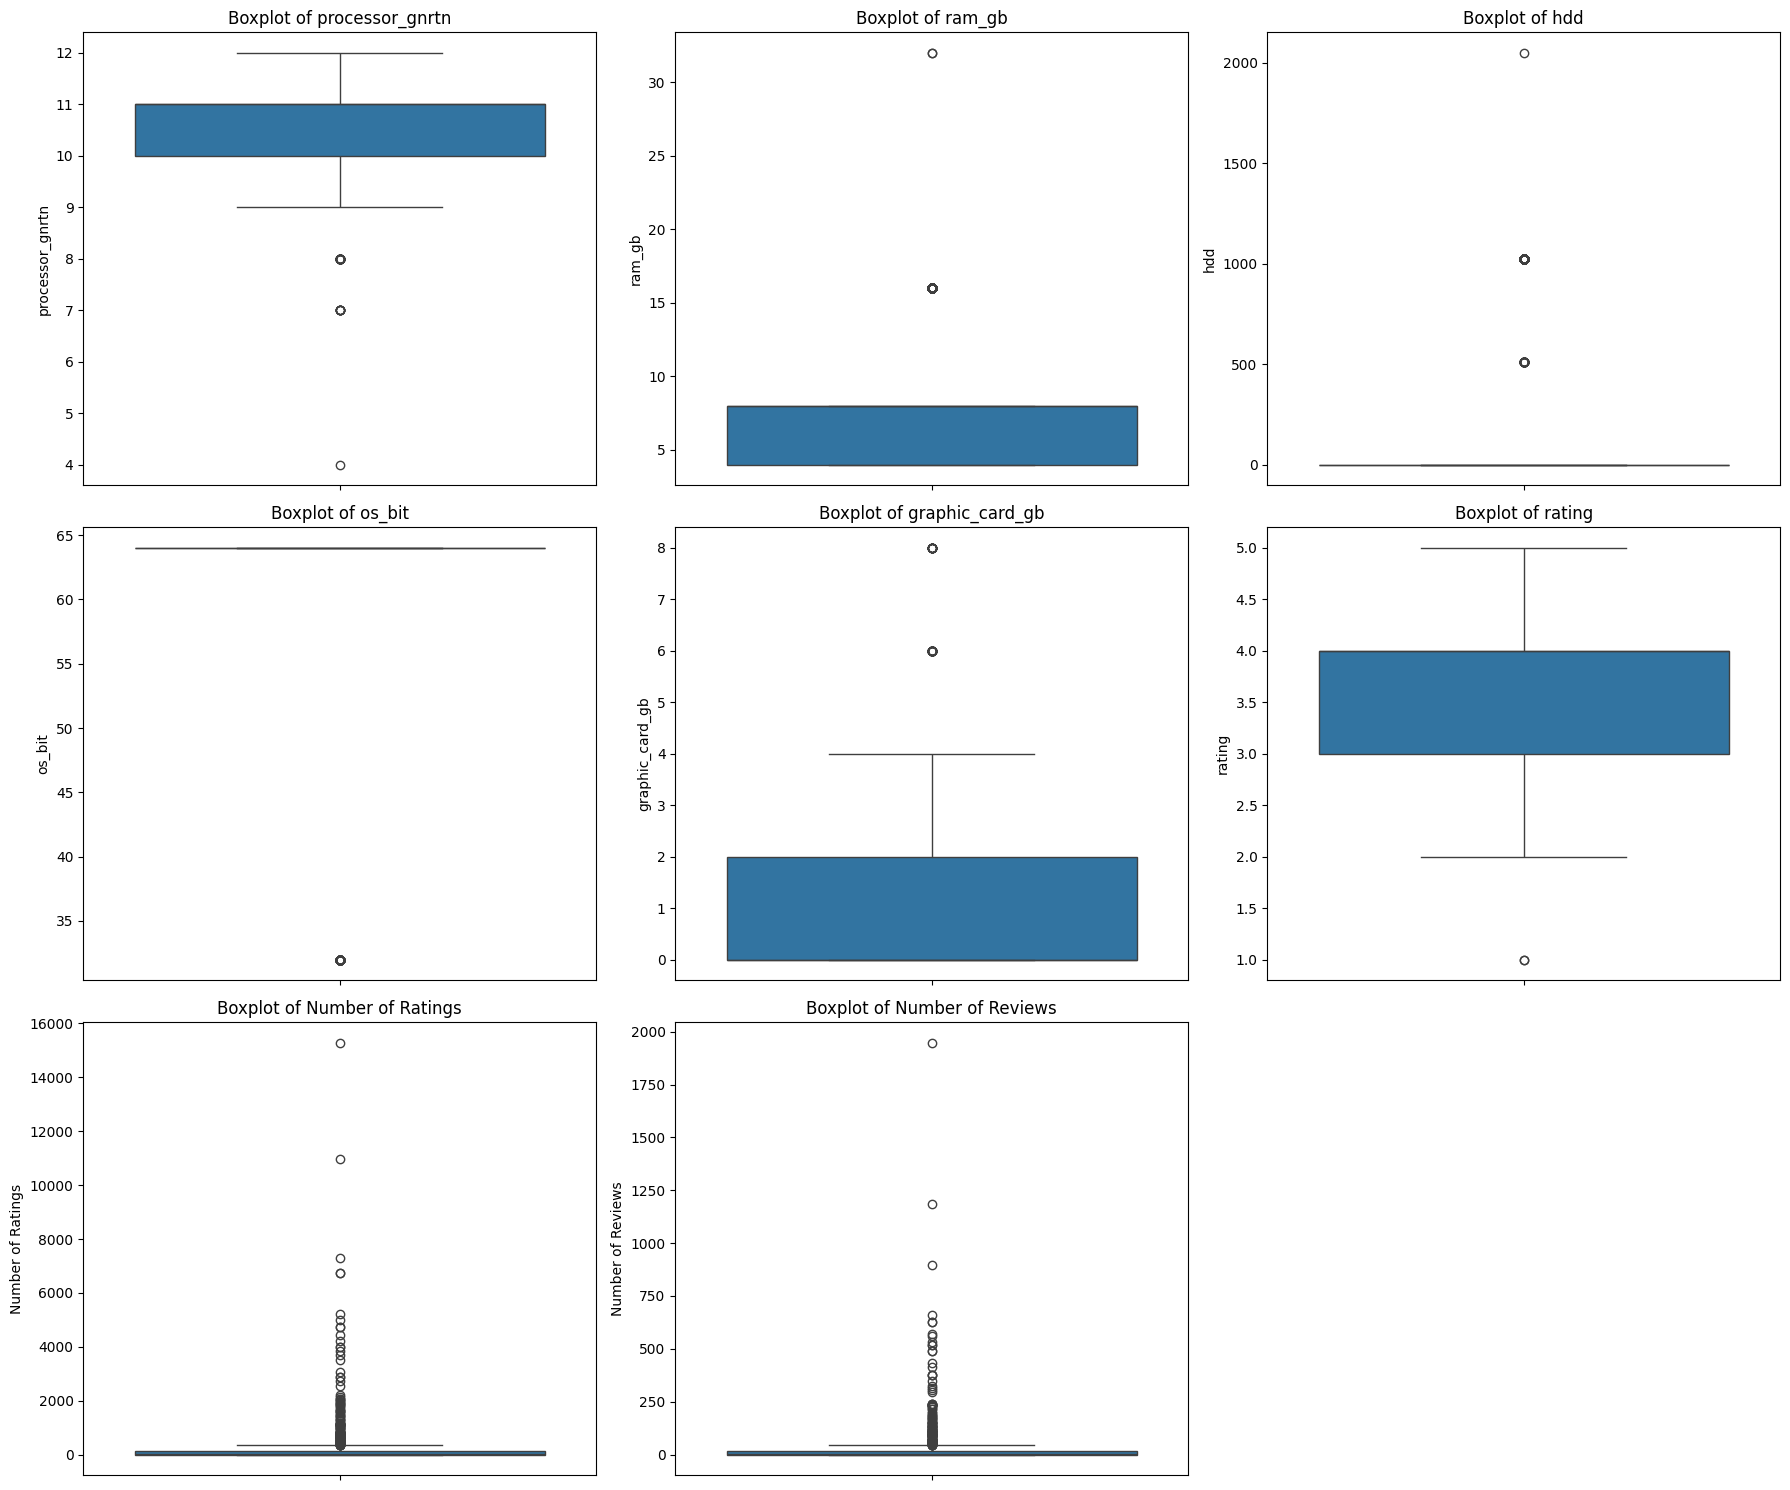

In [82]:
num_cols_for_boxplot = [col for col in numerical_cols if col != 'Price']
num_features_boxplot = len(num_cols_for_boxplot)
num_rows_boxplot = (num_features_boxplot + 2) // 3 # Roughly 3 columns per row

fig, axes = plt.subplots(num_rows_boxplot, 3, figsize=(18, num_rows_boxplot * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols_for_boxplot):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Remove any unused subplots if the number of features is not a perfect multiple of 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

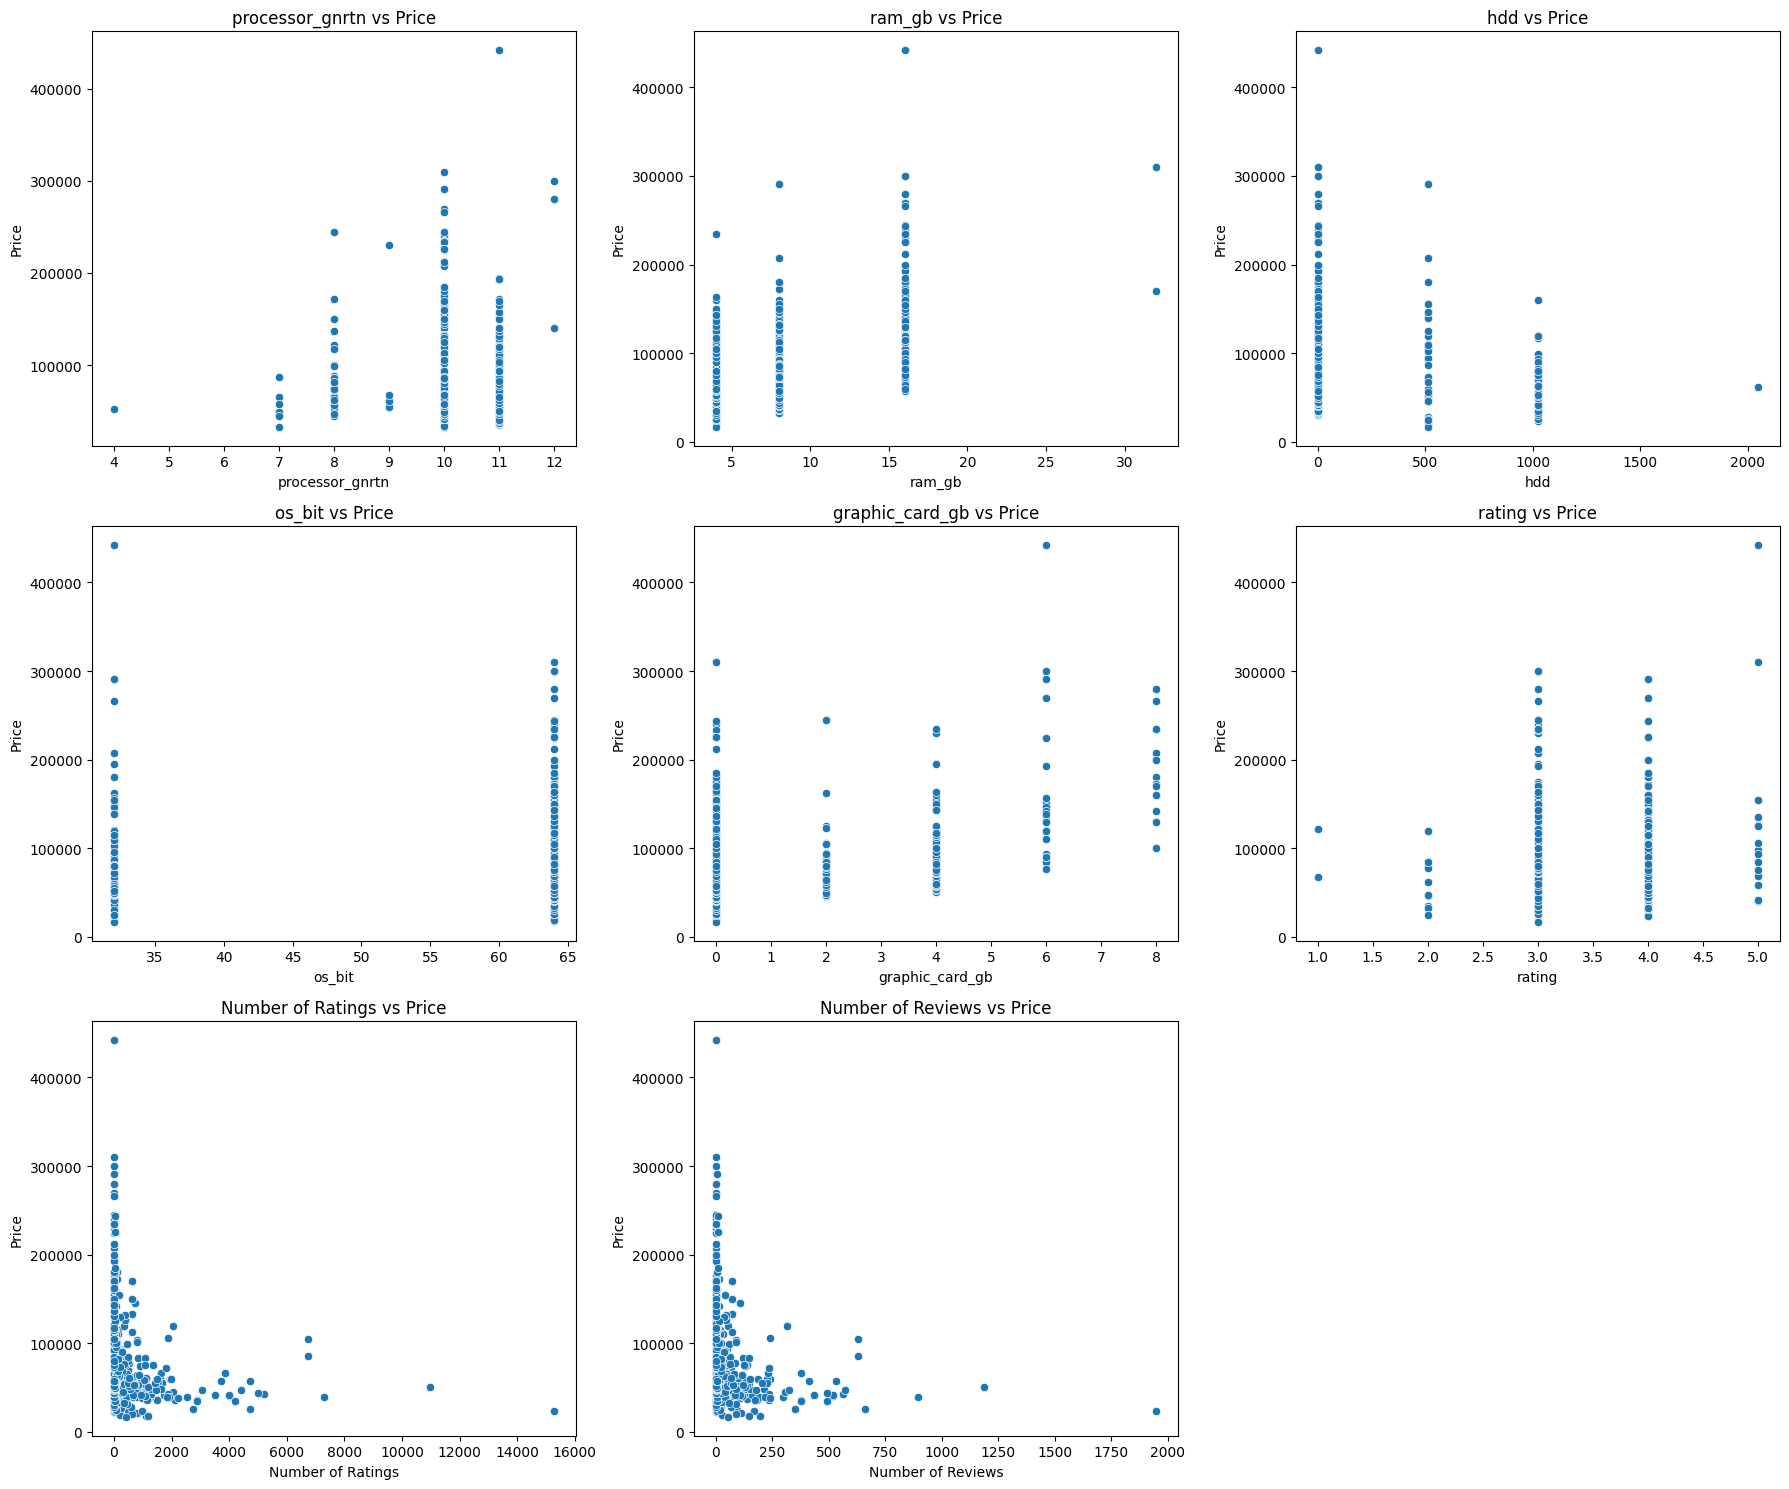

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64','float64','int32','float32']).columns.tolist()

# Remove target variable
if 'Price' in num_cols:
    num_cols.remove('Price')

num_features = len(num_cols)
num_rows = (num_features + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(x=df[col], y=df['Price'], ax=axes[i])
    axes[i].set_title(f'{col} vs Price')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

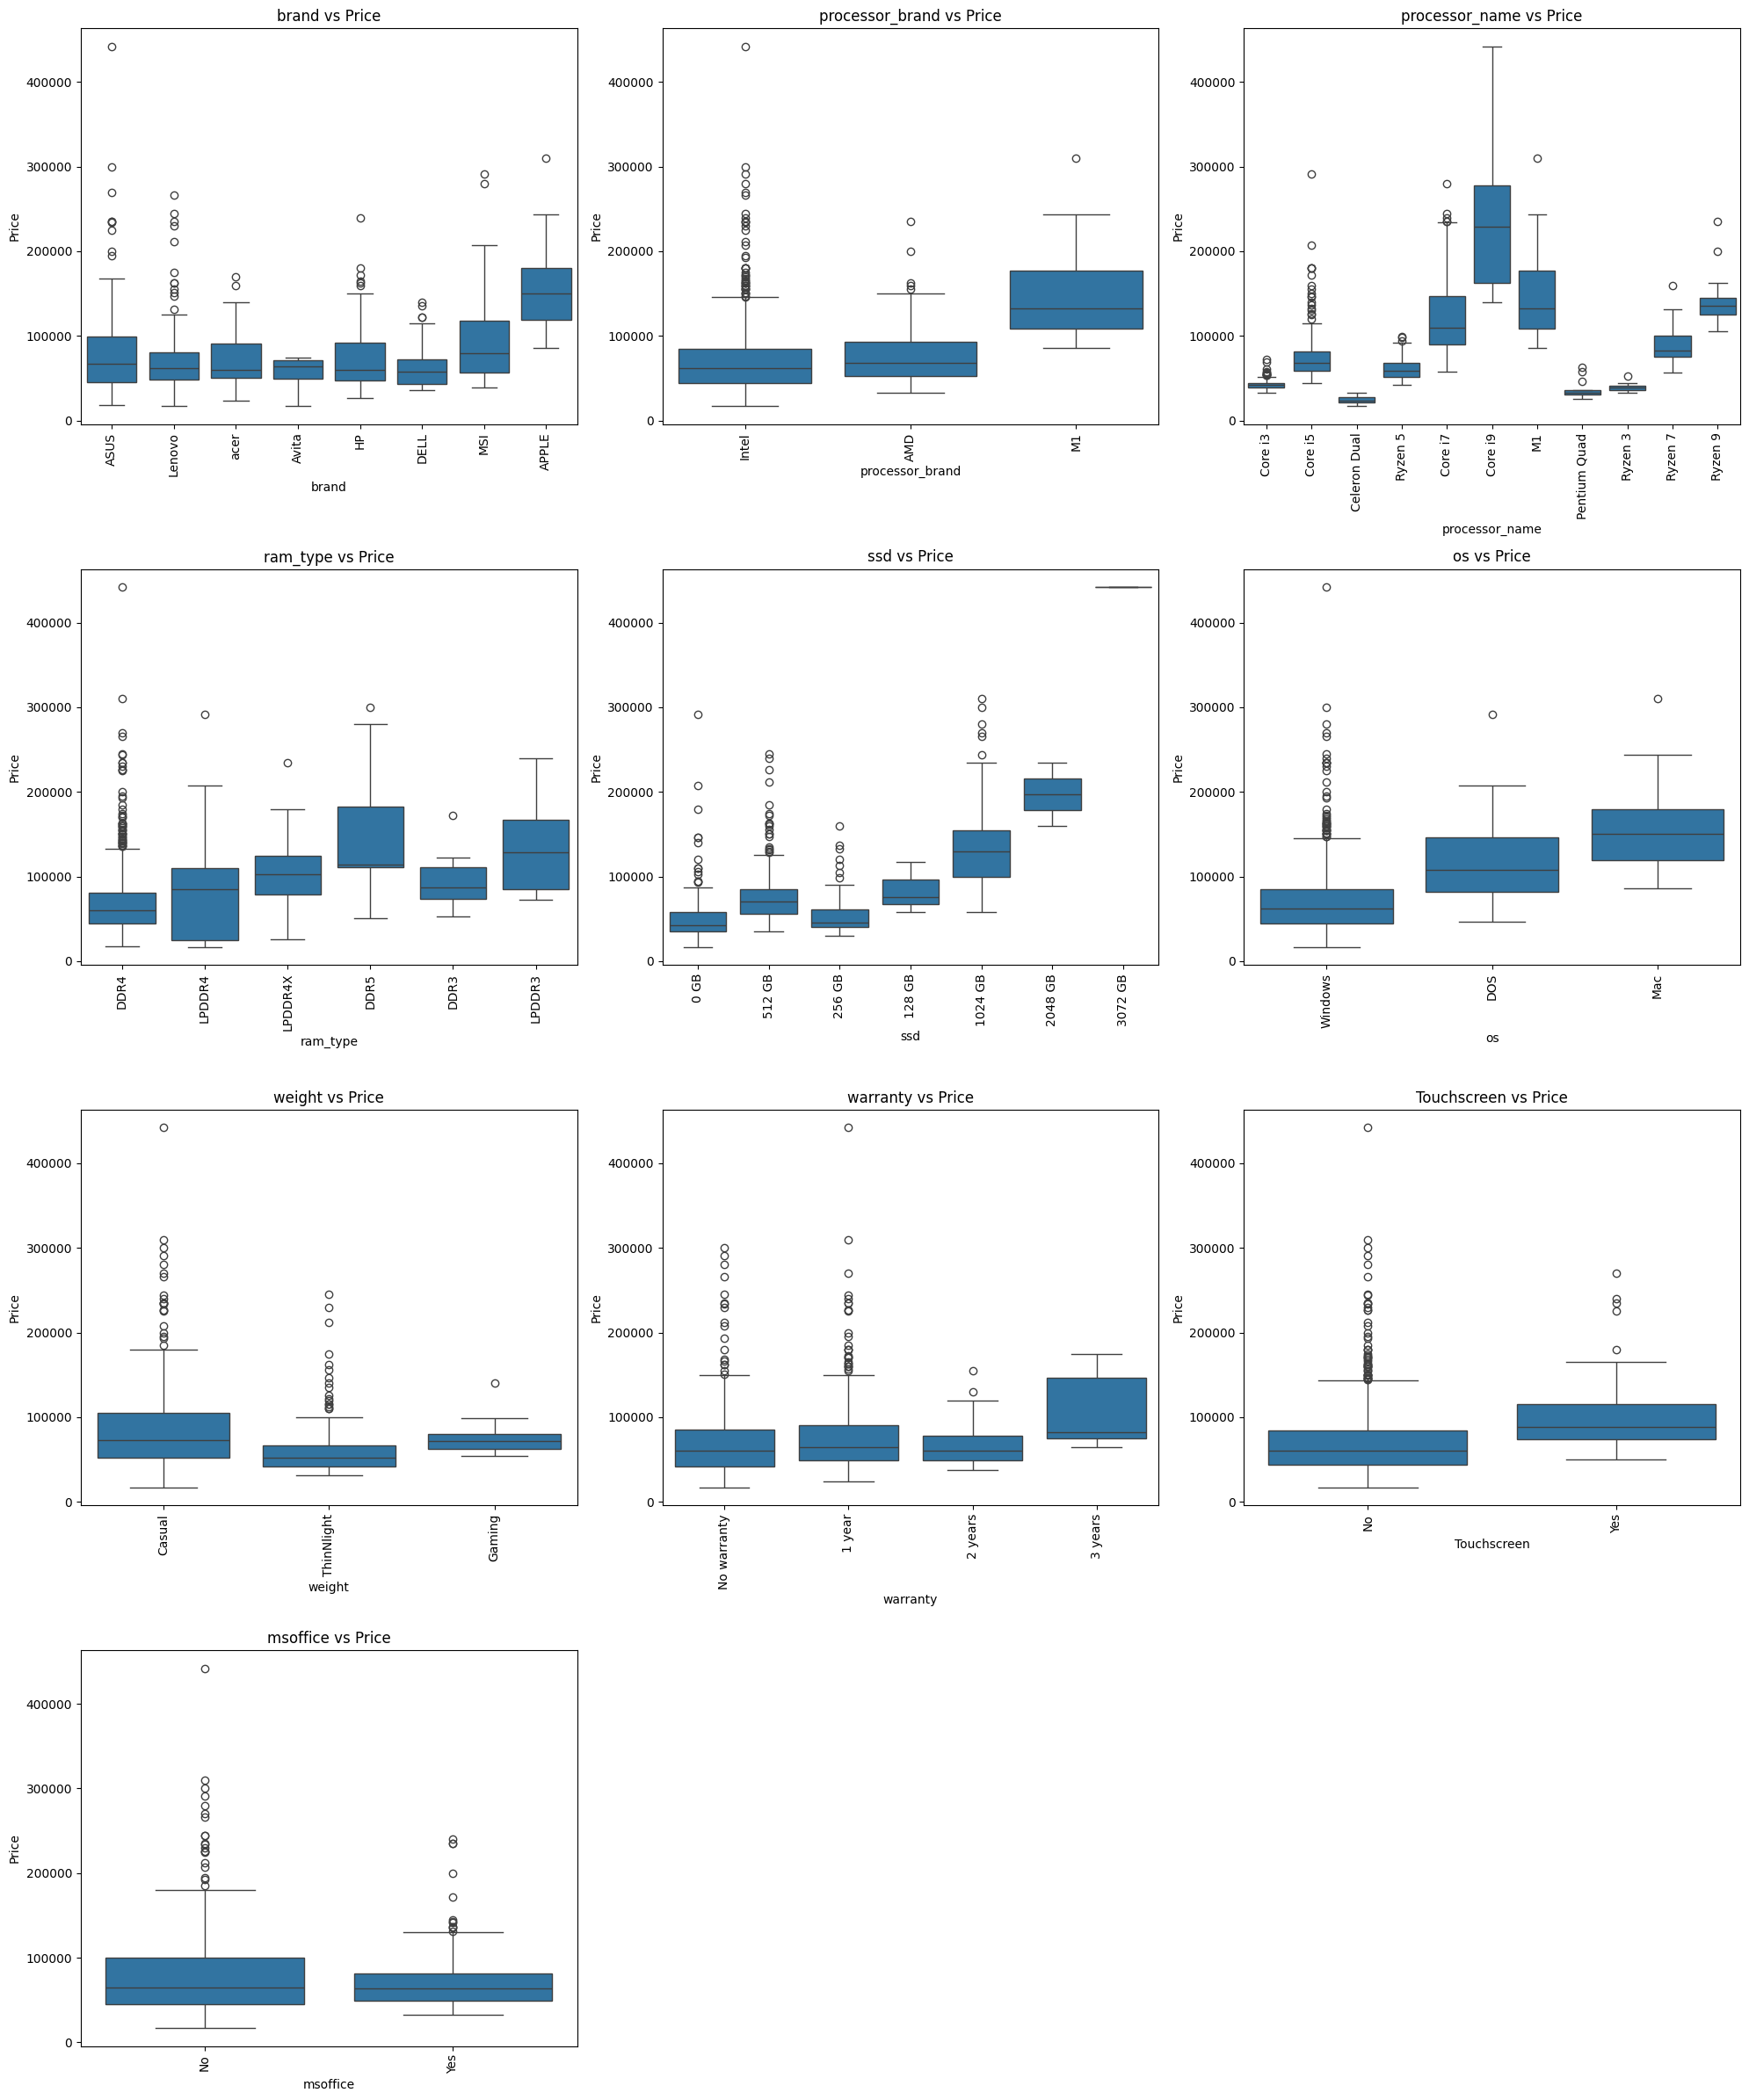

In [85]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

num_features = len(cat_cols)
num_rows = (num_features + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(20, num_rows * 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=df[col], y=df['Price'], ax=axes[i])
    axes[i].set_title(f'{col} vs Price')
    axes[i].tick_params(axis='x', rotation=90)

# Remove extra plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [94]:
df['processor_gnrtn'] = df['processor_gnrtn'].fillna(df['processor_gnrtn'].median())

In [95]:
df.isnull().sum()

,0
brand,0
processor_brand,0
processor_name,0
processor_gnrtn,0
ram_gb,0
ram_type,0
ssd,0
hdd,0
os,0
os_bit,0


visulize

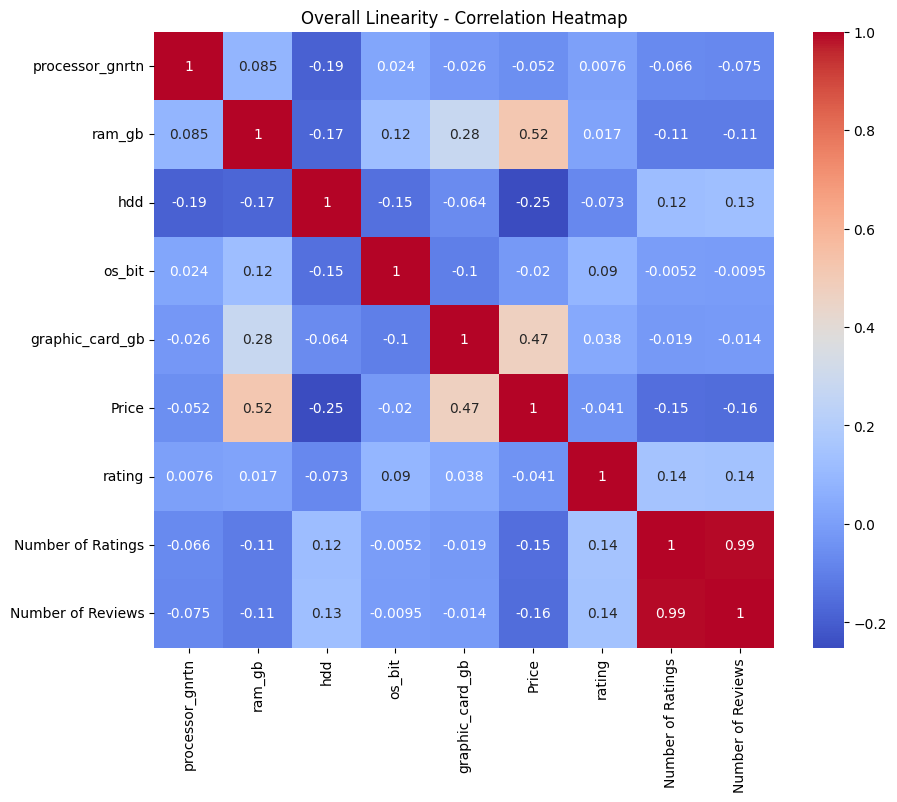

In [77]:
#for numerical
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Overall Linearity - Correlation Heatmap')
plt.show()